# YOLOv10n 1차 학습 (HaGRID 8개 클래스)

현재 학습 클래스 8개 (palm, fist, ok, three, like, call, rock, three2).
`three_gun`은 데이터 미확보로 제외, 추후 데이터 확보 시 이 가중치를 베이스로
9개 클래스 재학습 진행

## 0. 환경 설정

In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 33.3 MB/s eta 0:00:00


In [2]:
import torch
print("GPU 사용 가능:", torch.cuda.is_available())
print("GPU 이름:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "없음")

GPU 사용 가능: True
GPU 이름: Tesla T4


## 1. 데이터셋 업로드 / 경로 연결

Google Drive에 zip 올려서 마운트하는 방식

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [17]:
# ============================================================
# CONFIG
# ============================================================
import os

# Drive 데이터셋 경로
DRIVE_DATASET_ZIP = "/content/drive/MyDrive/HandSpark/hagrid_yolo(three_gun 없는 버전).zip"

# 코랩 로컬에 압축 풀 위치
LOCAL_DATA_DIR = "/content/data/hagrid_yolo/hagrid_yolo(three_gun 없는 버전)"

In [18]:
import os

os.makedirs(LOCAL_DATA_DIR, exist_ok=True)
!unzip -q "{DRIVE_DATASET_ZIP}" -d "{LOCAL_DATA_DIR}"

print("압축 해제 완료. 폴더 구조 확인:")
!find {LOCAL_DATA_DIR} -maxdepth 2

replace /content/data/hagrid_yolo/hagrid_yolo(three_gun 없는 버전)/hagrid_yolo(three_gun 없는 버전)/dataset.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
압축 해제 완료. 폴더 구조 확인:
/bin/bash: -c: line 1: syntax error near unexpected token `('
/bin/bash: -c: line 1: `find /content/data/hagrid_yolo/hagrid_yolo(three_gun 없는 버전) -maxdepth 2'


## 2. dataset.yaml 확인 및 경로 수정

로컬(Windows)에서 만든 yaml의 `path`가 코랩 경로와 다르므로 직접 덮어씀.

In [19]:
DATASET_YAML = f"{LOCAL_DATA_DIR}/dataset.yaml"

print("현재 dataset.yaml 내용:")
with open(DATASET_YAML, "r") as f:
    print(f.read())

현재 dataset.yaml 내용:
path: C:\Users\riwon\Downloads\data\hagrid_yolo
train: images/train
val: images/val
test: images/test

names:
  0: palm
  1: fist
  2: ok
  3: three
  4: like
  5: call
  6: rock
  7: three2
  # 8: three_gun



In [20]:
# path만 코랩 경로로 교체
with open(DATASET_YAML, "r") as f:
    lines = f.readlines()

with open(DATASET_YAML, "w") as f:
    for line in lines:
        if line.startswith("path:"):
            f.write(f"path: {LOCAL_DATA_DIR}\n")
        else:
            f.write(line)

print("수정된 dataset.yaml:")
with open(DATASET_YAML, "r") as f:
    print(f.read())

수정된 dataset.yaml:
path: /content/data/hagrid_yolo/hagrid_yolo(three_gun 없는 버전)
train: images/train
val: images/val
test: images/test

names:
  0: palm
  1: fist
  2: ok
  3: three
  4: like
  5: call
  6: rock
  7: three2
  # 8: three_gun



## 3. 학습 설정

In [21]:
# ============================================================
# CONFIG
# ============================================================

EPOCHS = 80
IMG_SIZE = 640
BATCH_SIZE = 16
PRETRAINED_WEIGHTS = "yolov10n.pt"   # COCO 사전학습 가중치
RUN_NAME = "hagrid_stage1_8cls"
PROJECT_DIR = "./runs"

# ============================================================

## 4. 모델 로드 및 학습

In [22]:
from ultralytics import YOLO

model = YOLO(PRETRAINED_WEIGHTS)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [25]:
results = model.train(
    data=DATASET_YAML,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    name=RUN_NAME,
    project=PROJECT_DIR,
    patience=15,
    save=True,
    plots=True,
)

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/hagrid_yolo/hagrid_yolo(three_gun 없는 버전)/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov10n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=hagrid_stage1_8cls, nbs=64, nms=False, opset=None, optimize=Fal

## 5. 학습 결과 확인

In [34]:
PROJECT_DIR = "/content/runs/detect/runs"
RUN_NAME = "hagrid_stage1_8cls"

weights_dir = f"{PROJECT_DIR}/{RUN_NAME}/weights"
print("가중치 파일 목록:")
for f in os.listdir(weights_dir):
    print(" -", f)

print(f"\n최종 가중치 경로 (다음 단계 fine-tuning에 사용):")
print(f"{weights_dir}/best.pt")

가중치 파일 목록:
 - last.pt
 - best.pt

최종 가중치 경로 (다음 단계 fine-tuning에 사용):
/content/runs/detect/runs/hagrid_stage1_8cls/weights/best.pt


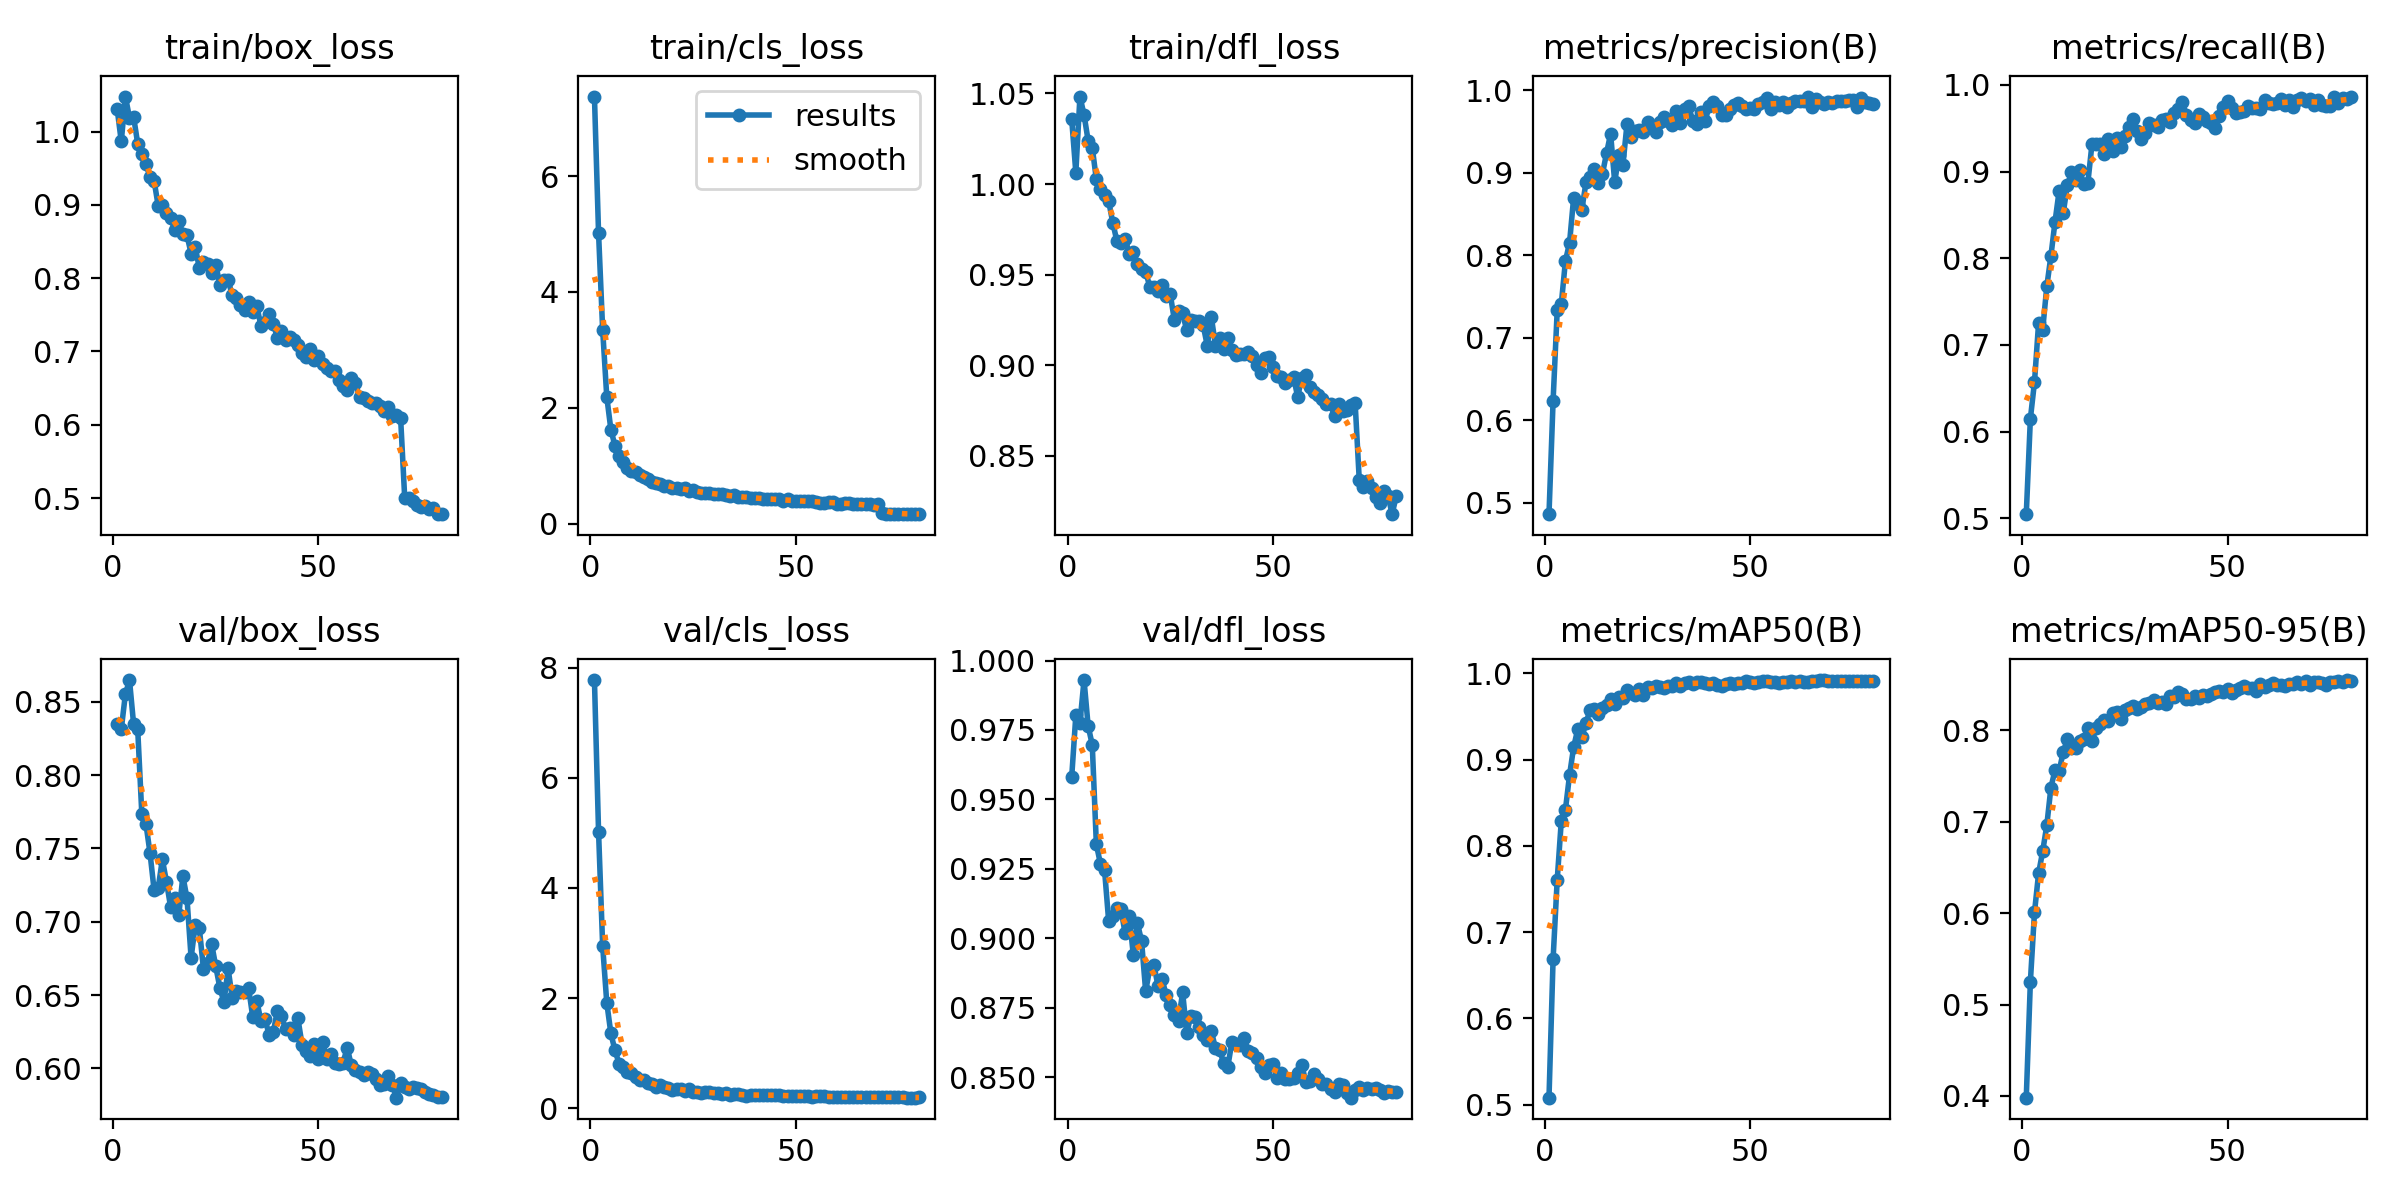

In [35]:
from IPython.display import Image as IPImage

# 학습 결과 그래프
IPImage(filename=f"{PROJECT_DIR}/{RUN_NAME}/results.png")

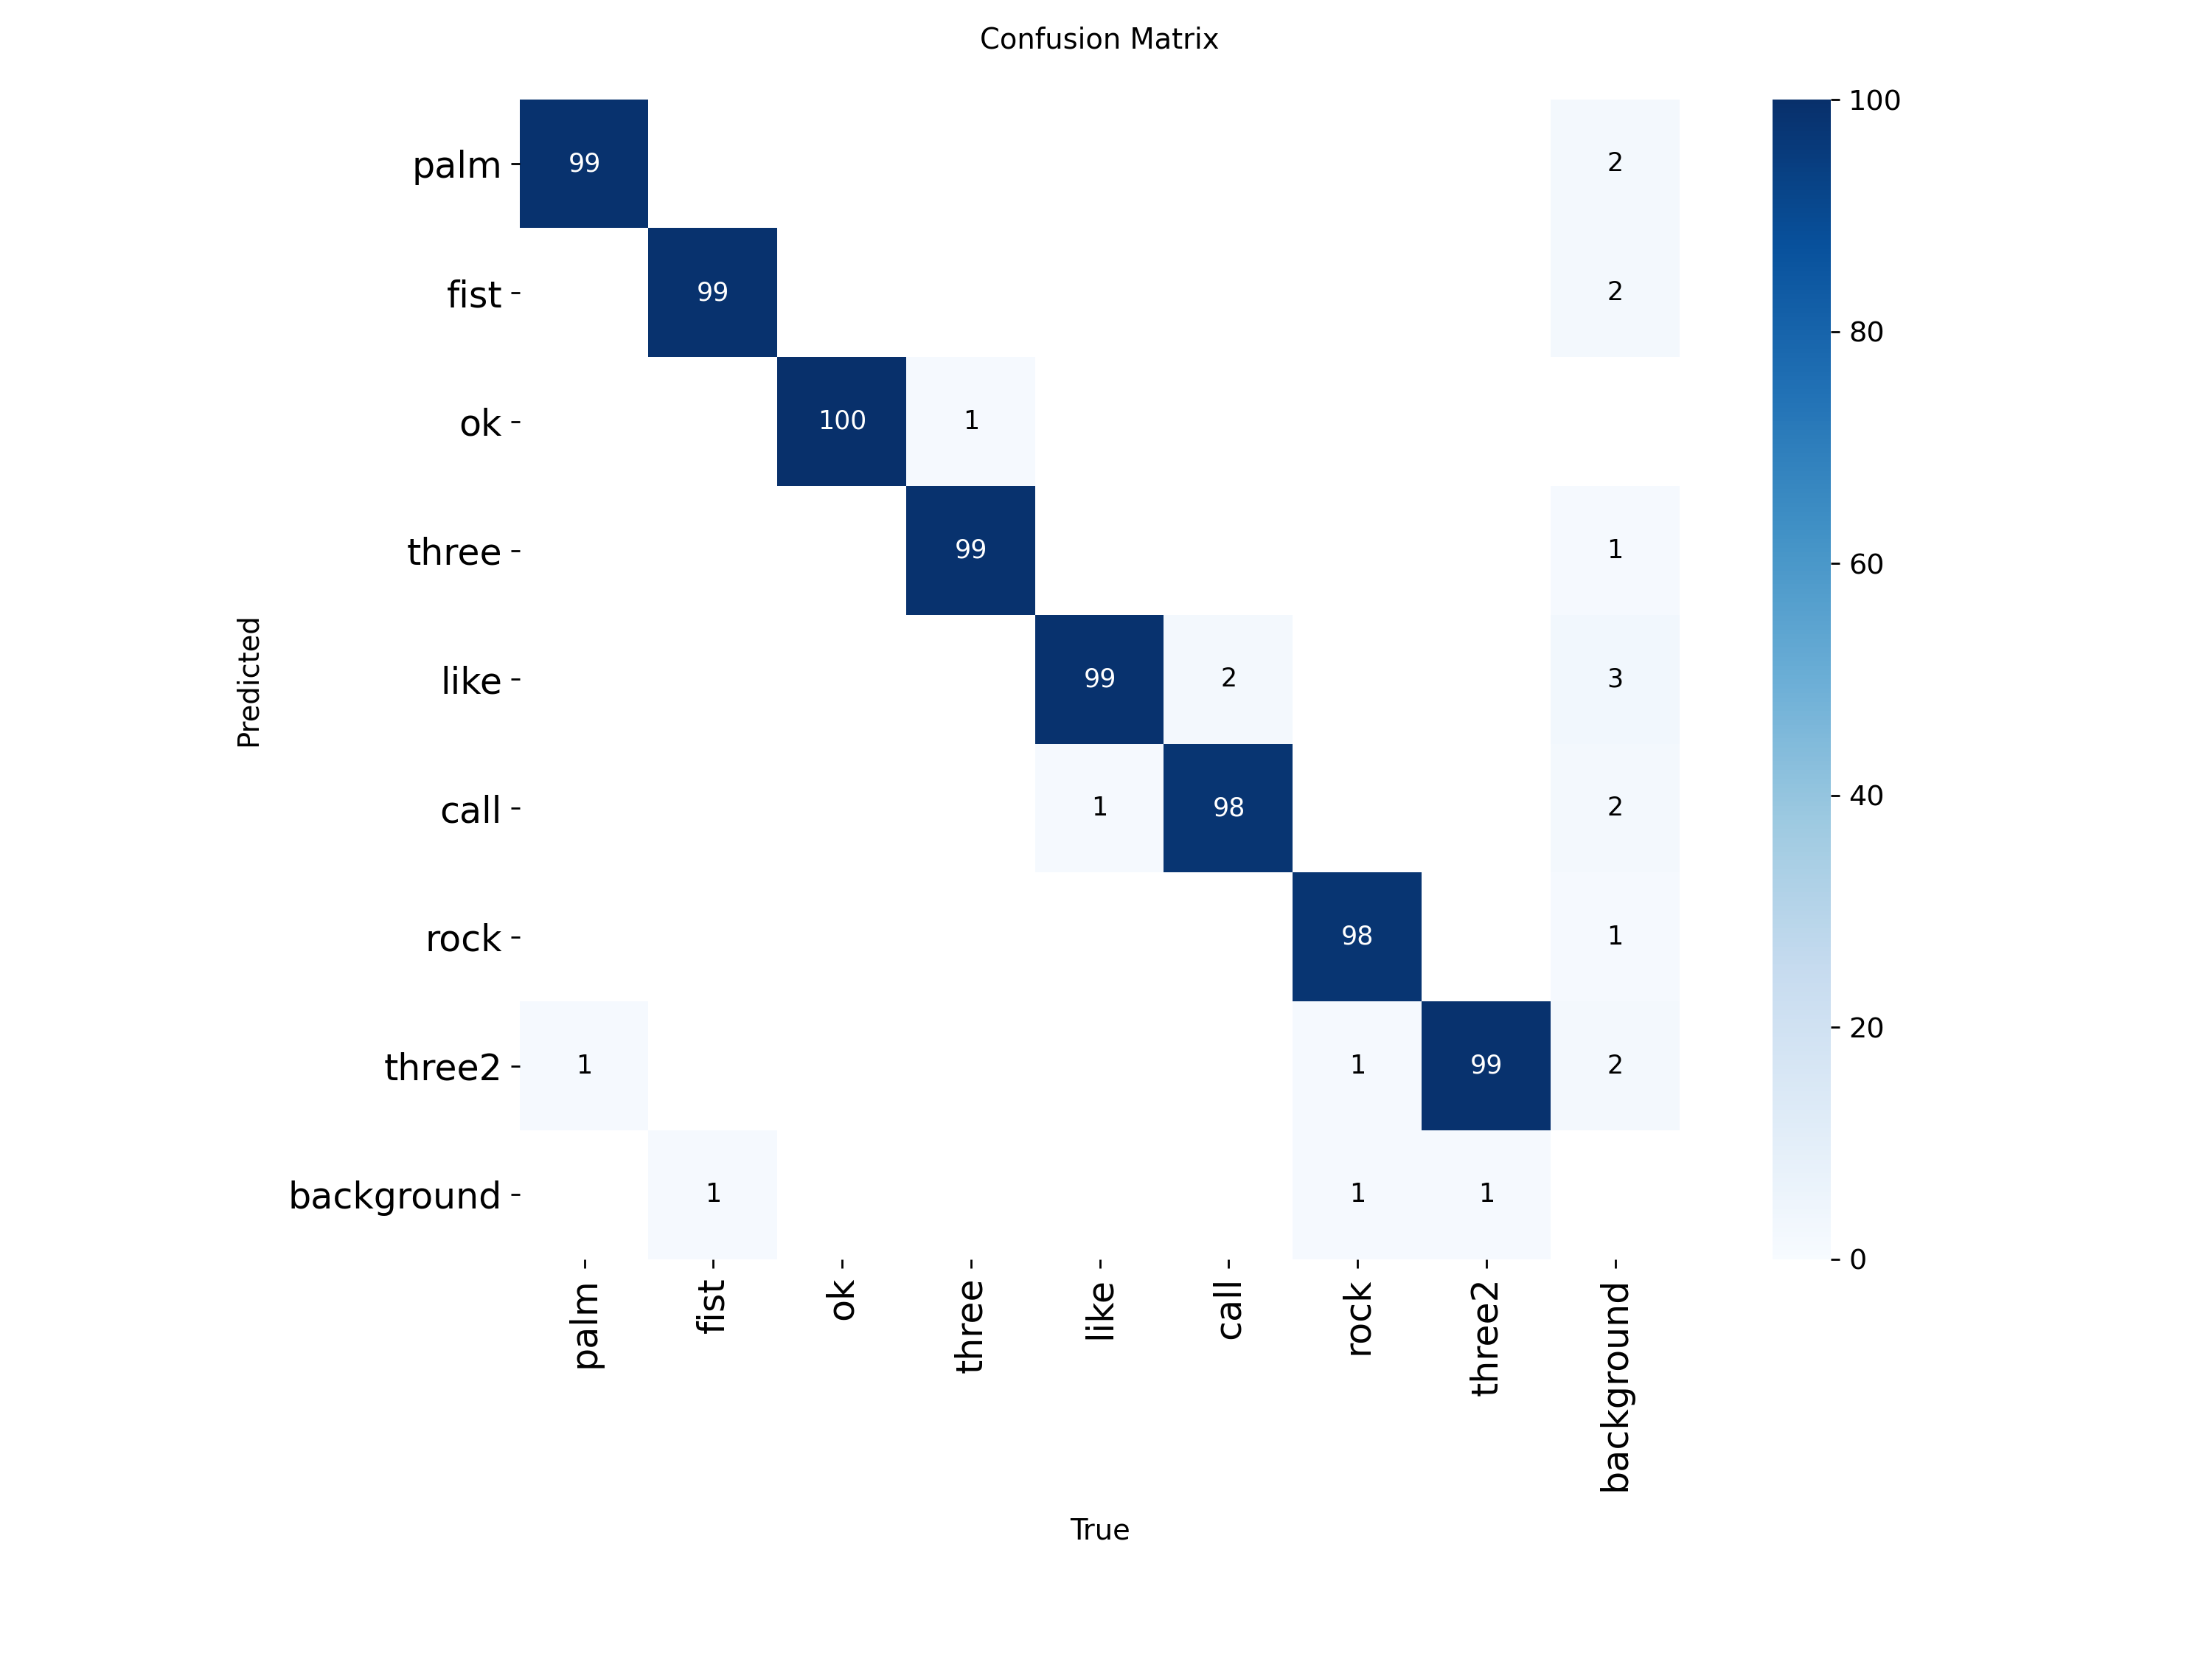

In [36]:
# confusion_matrix
IPImage(filename=f"{PROJECT_DIR}/{RUN_NAME}/confusion_matrix.png")

## 6. 검증셋 성능 평가

In [37]:
best_model = YOLO(f"{weights_dir}/best.pt")
metrics = best_model.val(data=DATASET_YAML)

print("\n=== 검증 결과 ===")
print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")

Ultralytics 8.4.70 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv10n summary (fused): 102 layers, 2,266,728 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 895.0±396.9 MB/s, size: 21.4 KB)
val: Scanning /content/data/hagrid_yolo/hagrid_yolo(three_gun 없는 버전)/labels/val.cache... 800 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 800/800 258.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 50/50 7.4it/s 6.8s
                   all        800        800      0.987      0.985      0.992      0.855
                  palm        100        100      0.988       0.99      0.994      0.902
                  fist        100        100      0.998       0.98      0.993      0.809
                    ok        100        100      0.988          1      0.995      0.885
                 three        100        100          1      0.985      0.995       0.83
         

## 7. 샘플 이미지로 추론 테스트

In [38]:
import glob

test_images = glob.glob(f"{LOCAL_DATA_DIR}/images/test/*.jpg")[:5]

if test_images:
    test_results = best_model.predict(test_images, save=True, conf=0.4)
    print(f"\n테스트 결과 저장 위치: {test_results[0].save_dir}")
else:
    print("테스트 이미지를 찾지 못함. 경로를 확인할 것.")


0: 640x640 1 like, 9.5ms
1: 640x640 1 three2, 9.5ms
2: 640x640 1 palm, 9.5ms
3: 640x640 1 three2, 9.5ms
4: 640x640 1 rock, 9.5ms
Speed: 3.5ms preprocess, 9.5ms inference, 0.3ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict

테스트 결과 저장 위치: /content/runs/detect/predict


In [39]:
if test_images:
    saved_files = os.listdir(test_results[0].save_dir)
    if saved_files:
        IPImage(filename=os.path.join(test_results[0].save_dir, saved_files[0]))

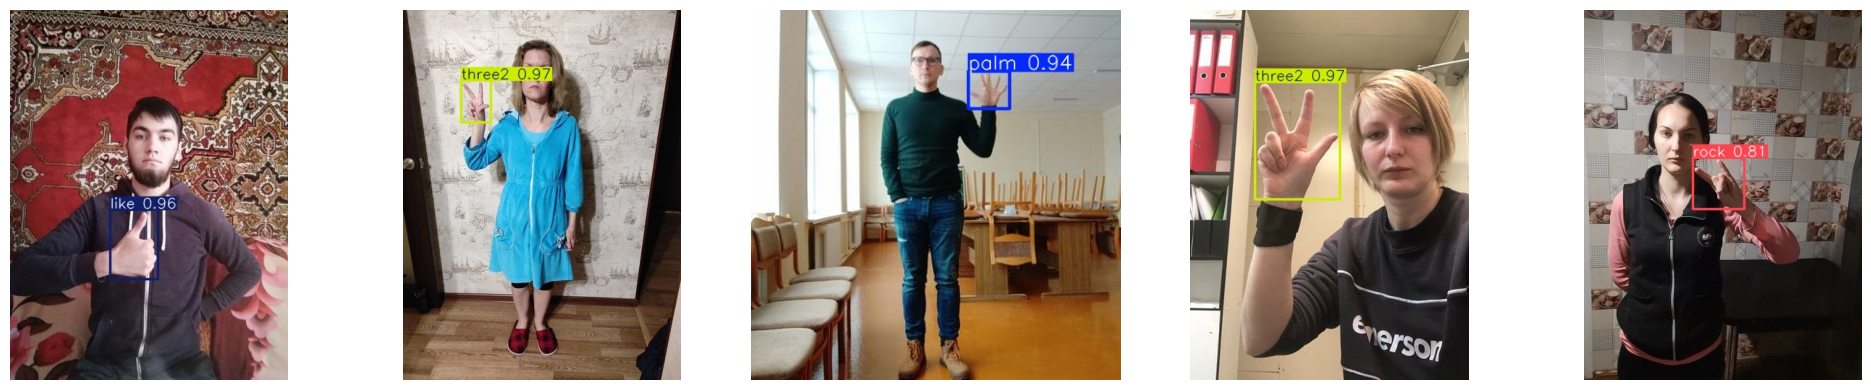

In [43]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, img_name in enumerate(['image0.jpg', 'image1.jpg', 'image2.jpg', 'image3.jpg', 'image4.jpg']):
    img = mpimg.imread(f"/content/runs/detect/predict/{img_name}")
    axes[i].imshow(img)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## 8. 가중치 Google Drive 백업

In [44]:
import shutil

DRIVE_SAVE_DIR = "/content/drive/MyDrive/HandSpark/weights"
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)

shutil.copy(f"{weights_dir}/best.pt", f"{DRIVE_SAVE_DIR}/hagrid_stage1_8cls_best.pt")
print(f"저장됨: {DRIVE_SAVE_DIR}/hagrid_stage1_8cls_best.pt")

저장됨: /content/drive/MyDrive/HandSpark/weights/hagrid_stage1_8cls_best.pt
